# 모델 B — EfficientNetB0 학습 + 모델 A와 성능 비교 (담당: 팀원2)

## 배경
- 기획 변경: 유사 페어 삭제 → 독버섯 7종 다중분류 (환자 대응용)
- 데이터: 7클래스, 총 1,781장 (불균형비 1.81배)
- EDA 혼동 위험 쌍: entoloma_rhodopolium ↔ omphalotus_japonicus (색상 유사도 0.873)

## ⚠️ 공정 비교를 위한 필수 조건
- 태윤(모델 A)과 **동일한 SEED, 동일한 train/val/test split, 동일한 class_weight** 사용
- 동일 IMG_SIZE(224x224), 동일 BATCH_SIZE(32)
- **EfficientNet은 preprocess_input이 모델 내장이라 ResNet과 전처리 코드가 다름** — 아래 코드 그대로 사용

## 작업 순서
1. 베이스라인 학습 (base freeze)
2. Fine-tuning (상위 30% unfreeze)
3. 테스트셋 평가 + Confusion Matrix
4. 모델 A와 성능 비교표 작성

---

## Cell 1 — 환경 설정

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/딥러닝/data/drive-download-20260703T022054Z-3-001.zip"   # 압축 파일 경로
extract_path = "/content/drive/MyDrive/Colab Notebooks/딥러닝/data/PoisonMushroom"        # 해제 경로

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_path)

print("압축 해제 완료:", os.listdir(extract_path))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/딥러닝/data/drive-download-20260703T022054Z-3-001.zip'

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/data/PoisonMushroom'

CLASS_NAMES = [
    'amanita_pantherina',
    'amanita_subjunquillea',
    'entoloma_rhodopolium',
    'omphalotus_japonicus',
    'hypholoma_fasciculare',
    'amanita_virosa',
    'trichoderma_cornudamae',
]
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42  # 태윤과 반드시 동일한 값 사용

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — 데이터 파이프라인 (모델 A와 동일 구조)

In [13]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    class_names=CLASS_NAMES
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    class_names=CLASS_NAMES
)

val_batches = tf.data.experimental.cardinality(val_test_ds)
test_ds = val_test_ds.take(val_batches // 2)
val_ds = val_test_ds.skip(val_batches // 2)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.1),
])

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

Found 1781 files belonging to 7 classes.
Using 1247 files for training.
Found 1781 files belonging to 7 classes.
Using 534 files for validation.
Train batches: 39
Val batches: 9
Test batches: 8


## Cell 3 — class_weight 계산 (모델 A와 동일 값이어야 함)

In [14]:
from sklearn.utils.class_weight import compute_class_weight

y_train_labels = []
for images, labels in train_ds.unbatch():
    y_train_labels.append(np.argmax(labels.numpy()))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=np.array(y_train_labels)
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

print("적용할 class_weight:")
for cls, idx in zip(CLASS_NAMES, range(NUM_CLASSES)):
    print(f"  {cls}: {class_weight_dict[idx]:.3f}")

적용할 class_weight:
  amanita_pantherina: 1.142
  amanita_subjunquillea: 1.180
  entoloma_rhodopolium: 1.080
  omphalotus_japonicus: 1.086
  hypholoma_fasciculare: 0.995
  amanita_virosa: 0.704
  trichoderma_cornudamae: 0.995


## Cell 4 — 모델 구조 (EfficientNetB0)

In [15]:
def build_efficientnetb0(num_classes, img_size=(224, 224)):
    base_model = EfficientNetB0(
        input_shape=img_size + (3,),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=img_size + (3,))
    x = data_augmentation(inputs)
    # EfficientNet은 자체 preprocess가 내장돼 있어 별도 preprocess_input 불필요
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    return model, base_model

model_b, base_b = build_efficientnetb0(NUM_CLASSES)
model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_b.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Cell 5 — 1단계: 베이스라인 학습

In [17]:
os.makedirs('/content/drive/MyDrive/PoisonMushroom/models', exist_ok=True)

callbacks_stage1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/PoisonMushroom/models/model_b_stage1.keras',
        monitor='val_accuracy', save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
    )
]

history_b_stage1 = model_b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage1
)

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7963 - loss: 0.9068

KeyboardInterrupt: 

# Cell 5-2 베스트 모델 이어서 학습

In [26]:
model_b = tf.keras.models.load_model(
    '/content/drive/MyDrive/PoisonMushroom/models/model_b_stage1.keras'
)

callbacks_stage1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/PoisonMushroom/models/model_b_2.keras',
        monitor='val_accuracy', save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
    )
]


# EarlyStopping이 알아서 val_loss 안 좋아지면 멈춰줌
history_b_stage1_resumed = model_a.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,  # 추가로 더 돌릴 epoch 수
    class_weight=class_weight_dict,
    callbacks=callbacks_stage1
)

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 0.9767 - loss: 0.1098 - val_accuracy: 0.9388 - val_loss: 0.2125 - learning_rate: 5.0000e-04
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.9727 - loss: 0.1012 - val_accuracy: 0.9388 - val_loss: 0.2086 - learning_rate: 5.0000e-04
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.9808 - loss: 0.0950 - val_accuracy: 0.9388 - val_loss: 0.2090 - learning_rate: 5.0000e-04
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.9783 - loss: 0.1035 - val_accuracy: 0.9388 - val_loss: 0.2064 - learning_rate: 5.0000e-04
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.9791 - loss: 0.1009 - val_accuracy: 0.9424 - val_loss: 0.2037 - learning_rate: 5.0000e-04
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.9808 - loss: 0.0973 - val_accuracy: 0.9388 - val_loss: 0.2048 - learning_rate: 5.0000e-04
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.9

## Cell 6 — 1단계 학습 곡선

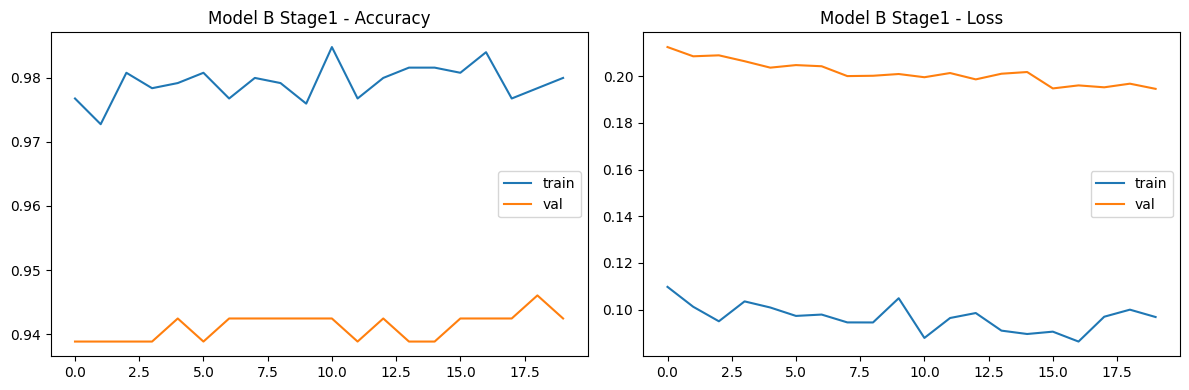

Stage1 최고 val_accuracy: 0.9460431933403015


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_b_stage1_resumed.history['accuracy'], label='train')
axes[0].plot(history_b_stage1_resumed.history['val_accuracy'], label='val')
axes[0].set_title('Model B Stage1 - Accuracy')
axes[0].legend()

axes[1].plot(history_b_stage1_resumed.history['loss'], label='train')
axes[1].plot(history_b_stage1_resumed.history['val_loss'], label='val')
axes[1].set_title('Model B Stage1 - Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Stage1 최고 val_accuracy:", max(history_b_stage1_resumed.history['val_accuracy']))

## Cell 7 — 2단계: Fine-tuning 준비

In [31]:
model_b = tf.keras.models.load_model(
    '/content/drive/MyDrive/PoisonMushroom/models/model_b_stage1.keras'
)

# model_b.summary() 로 base_model 위치(인덱스) 먼저 확인할 것
base_b = model_b.layers[2]  # data_aug 다음 (EfficientNet은 별도 preprocess 레이어 없음)
base_b.trainable = True

total_layers = len(base_b.layers)
fine_tune_at = int(total_layers * 0.7)

for layer in base_b.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_b.layers[fine_tune_at:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print(f"전체 레이어: {total_layers}, Fine-tune 시작 지점: {fine_tune_at}")
print(f"학습 가능 레이어 수: {sum([l.trainable for l in base_b.layers])}")

model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

전체 레이어: 238, Fine-tune 시작 지점: 166
학습 가능 레이어 수: 57


## Cell 8 — 2단계: Fine-tuning 학습

In [33]:
callbacks_stage2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/PoisonMushroom/models/model_b_finetuned.keras',
        monitor='val_accuracy', save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7
    )
]

initial_epoch = len(history_b_stage1_resumed.history['loss'])

history_b_stage2 = model_b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epoch + 15,
    initial_epoch=initial_epoch,
    class_weight=class_weight_dict,
    callbacks=callbacks_stage2
)

Epoch 21/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 27s 305ms/step - accuracy: 0.9575 - loss: 0.1699 - val_accuracy: 0.9388 - val_loss: 0.2446 - learning_rate: 1.0000e-05
Epoch 22/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.9599 - loss: 0.1404 - val_accuracy: 0.9353 - val_loss: 0.2340 - learning_rate: 1.0000e-05
Epoch 23/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - accuracy: 0.9663 - loss: 0.1253 - val_accuracy: 0.9353 - val_loss: 0.2269 - learning_rate: 1.0000e-05
Epoch 24/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.9663 - loss: 0.1084 - val_accuracy: 0.9317 - val_loss: 0.2150 - learning_rate: 1.0000e-05
Epoch 25/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.9671 - loss: 0.1100 - val_accuracy: 0.9353 - val_loss: 0.2139 - learning_rate: 1.0000e-05
Epoch 26/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.9671 - loss: 0.1140 - val_accuracy: 0.9353 - val_loss: 0.2093 - learning_rate: 1.0000e-05
Epoch 27/35
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - ac

## Cell 9 — 전체 학습 곡선

In [36]:
# 1. 나눔고딕 폰트 설치
!apt-get -qq install fonts-nanum
!fc-cache -fv

# 2. matplotlib에 폰트 등록
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

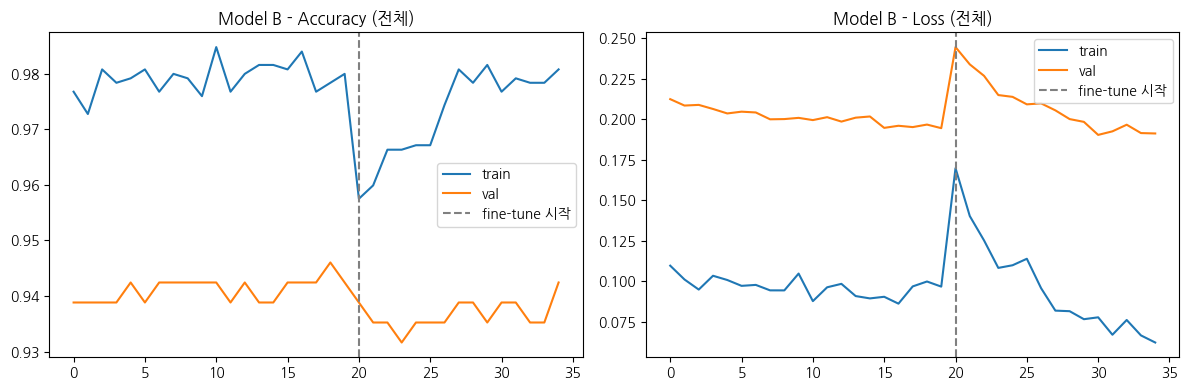

최종 최고 val_accuracy: 0.9460431933403015


In [40]:
acc = history_b_stage1_resumed.history['accuracy'] + history_b_stage2.history['accuracy']
val_acc = history_b_stage1_resumed.history['val_accuracy'] + history_b_stage2.history['val_accuracy']
loss = history_b_stage1_resumed.history['loss'] + history_b_stage2.history['loss']
val_loss = history_b_stage1_resumed.history['val_loss'] + history_b_stage2.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(acc, label='train')
axes[0].plot(val_acc, label='val')
axes[0].axvline(initial_epoch, color='gray', linestyle='--', label='fine-tune 시작')
axes[0].set_title('Model B - Accuracy (전체)')
axes[0].legend()

axes[1].plot(loss, label='train')
axes[1].plot(val_loss, label='val')
axes[1].axvline(initial_epoch, color='gray', linestyle='--', label='fine-tune 시작')
axes[1].set_title('Model B - Loss (전체)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("최종 최고 val_accuracy:", max(val_acc))

## Cell 10 — 테스트셋 평가 + Confusion Matrix

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.9531 - loss: 0.1468
Test Accuracy: 0.9531, Test Loss: 0.1468

분류 리포트:
                        precision    recall  f1-score   support

    amanita_pantherina       0.88      0.94      0.91        32
 amanita_subjunquillea       0.95      0.91      0.93        22
  entoloma_rhodopolium       1.00      0.87      0.93        38
  omphalotus_japonicus       0.93      1.00      0.97        28
 hypholoma_fasciculare       0.92      0.94      0.93        35
        amanita_virosa       0.97      0.98      0.97        57
trichoderma_cornudamae       1.00      1.00      1.00        44

              accuracy                           0.95       256
             macro avg       0.95      0.95      0.95       256
          weighted avg       0.95      0.95      0.95       256



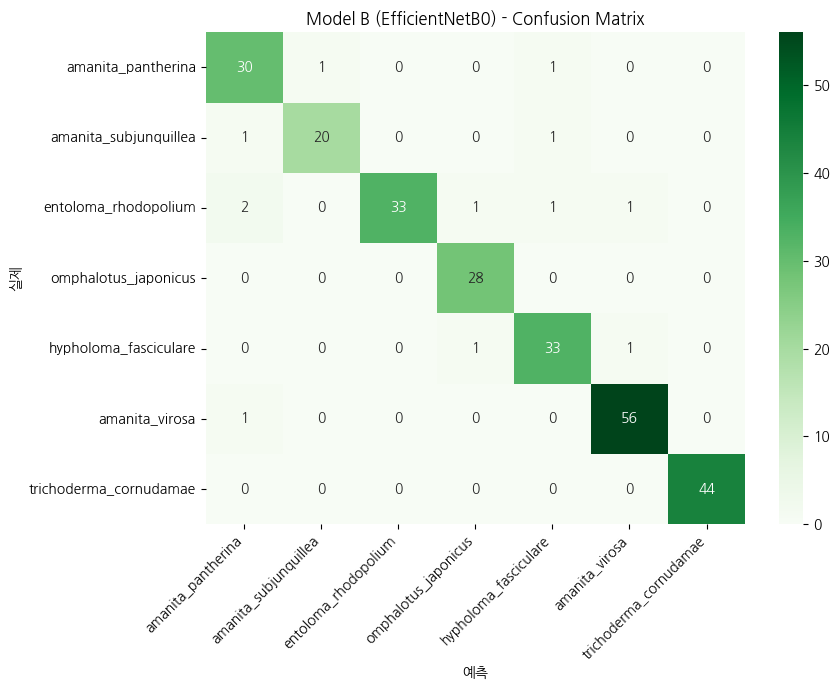

In [38]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time

start_time = time.time()
test_loss, test_acc = model_b.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model_b.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print("\n분류 리포트:")
report_b = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('예측')
plt.ylabel('실제')
plt.title('Model B (EfficientNetB0) - Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Cell 11 — 모델 A vs B 비교표 (태윤의 결과값을 받아서 채울 것)

In [39]:
import json
import pandas as pd

# 태윤에게 모델 A의 test_acc, classification_report 결과를 받아서 아래 값 채우기
model_a_params = 23579143      # model_a.count_params() 결과 공유받기
model_a_test_acc = 0.9258    # 태윤의 test_acc 공유받기

comparison = pd.DataFrame({
    'Model': ['ResNet50V2 + FineTunning(A)', 'EfficientNetB0 + FineTunning (B)'],
    'Params': [model_a_params, model_b.count_params()],
    'Test_Accuracy': [model_a_test_acc, test_acc],
})
print(comparison)



with open('/content/drive/MyDrive/PoisonMushroom/report_a.json') as f:
    report_a = json.load(f)

# 클래스별 f1-score 비교  - A
f1_a = {cls: report_a[cls]['f1-score'] for cls in CLASS_NAMES}
print("\n모델 A 클래스별 F1-score:")
for cls, f1 in f1_a.items():
    print(f"  {cls}: {f1:.3f}")

# 클래스별 f1-score 비교 - B
f1_b = {cls: report_b[cls]['f1-score'] for cls in CLASS_NAMES}
print("\n모델 B 클래스별 F1-score:")
for cls, f1 in f1_b.items():
    print(f"  {cls}: {f1:.3f}")



                              Model    Params  Test_Accuracy
0       ResNet50V2 + FineTunning(A)  23579143       0.925800
1  EfficientNetB0 + FineTunning (B)   4058538       0.953125

모델 A 클래스별 F1-score:
  amanita_pantherina: 0.889
  amanita_subjunquillea: 0.844
  entoloma_rhodopolium: 0.842
  omphalotus_japonicus: 0.930
  hypholoma_fasciculare: 0.903
  amanita_virosa: 0.964
  trichoderma_cornudamae: 0.966

모델 B 클래스별 F1-score:
  amanita_pantherina: 0.909
  amanita_subjunquillea: 0.930
  entoloma_rhodopolium: 0.930
  omphalotus_japonicus: 0.966
  hypholoma_fasciculare: 0.930
  amanita_virosa: 0.974
  trichoderma_cornudamae: 1.000


---

## 검증 체크리스트
- [ ] SEED, class_weight, split이 태윤과 동일한지 확인
- [ ] entoloma_rhodopolium ↔ omphalotus_japonicus 오분류 건수 확인
- [ ] 모델 A/B 비교표 작성 (파라미터 수, test accuracy, 클래스별 f1-score)
- [ ] 학습된 모델(.keras), 학습곡선, confusion matrix, 비교표 팀장에게 전달